# Exploratory Data Analysis (EDA) — Drug Delivery Dataset

---

**Pipeline stage:** `Gold → EDA (Python Analysis)`

**Objective:** Explore the Gold Layer Star Schema (1 Fact table + 7 Dimension tables) to surface key insights about nanoparticle biodistribution behavior — physical design, targeting strategy, tumor biology, shell chemistry, time/dosage dynamics, responsive release, selectivity, organic vs. inorganic comparison, cross-dimensional patterns, and data quality.

**Input:** `Fact_Biodistribution.csv`, `Dim_Nanoparticle.csv`, `Dim_Tumor.csv`, `Dim_Time.csv`, `Dim_Targeting_Strategy.csv`, `Dim_Organ.csv`, `Dim_Administration.csv`, `Dim_Efficiency.csv` (Gold Layer v2 — 7-Dimension Star Schema)

**Environment:** Google Colab

**Scope:** This notebook reports what the data shows — distributions, averages, correlations, comparisons. It does not draw conclusions or make recommendations; that is left for the Dashboard / BI stage.

---

### Structure

| # | Category | Focus |
|---|----------|-------|
| 0 | Setup | Load all 8 Gold tables and join into one analysis-ready flat table |
| 1 | Overview & Dataset Summary | KPI cards: counts, averages, key ratios |
| 2 | Nanoparticle Physical Design | Size, Zeta potential, Shape, Core material |
| 3 | Targeting Strategy Performance | Active vs. Passive targeting |
| 4 | Tumor Biology & Organ Targeting | Tumor sites, cell lines, organ biodistribution |
| 5 | Surface Coating & Shell Analysis | Shell Type, PEGylation |
| 6 | Time Point & Dosage Analysis | Temporal dynamics, dosage relationships |
| 7 | Responsive Release Mechanisms | Stimulus-responsive release behavior |
| 8 | Selectivity & Efficiency Performance | Selectivity_Index, Targeting_Efficiency |
| 9 | Inorganic vs. Organic NPs Comparison | NP_Class comparison |


## 0. Setup & Load the Gold Layer Star Schema

### 0.1 Mount Google Drive
Run this cell only if the Gold Layer CSVs are stored on Google Drive.

In [ ]:
# Mount Google Drive (skip if files are uploaded locally)
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 0.2 Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

COLOR   = '#2E75B6'
PALETTE = 'Blues_r'
print("Libraries ready.")

Libraries ready.


### 0.3 Load All 8 Gold Layer Tables

In [ ]:
# ── Update GOLD_PATH to wherever your Gold CSVs live ──────────────────────
GOLD_PATH = '/content/drive/MyDrive/Drug Delivery Project/1- Medallion Architecture/3- Gold'
# If uploaded directly to Colab session, use:
# GOLD_PATH = '/content'

fact               = pd.read_csv(f'{GOLD_PATH}/Fact_Biodistribution.csv')
dim_nanoparticle   = pd.read_csv(f'{GOLD_PATH}/Dim_Nanoparticle.csv')
dim_tumor          = pd.read_csv(f'{GOLD_PATH}/Dim_Tumor.csv')
dim_time           = pd.read_csv(f'{GOLD_PATH}/Dim_Time.csv')
dim_targeting      = pd.read_csv(f'{GOLD_PATH}/Dim_Targeting_Strategy.csv')
dim_organ          = pd.read_csv(f'{GOLD_PATH}/Dim_Organ.csv')
dim_administration = pd.read_csv(f'{GOLD_PATH}/Dim_Administration.csv')
dim_efficiency     = pd.read_csv(f'{GOLD_PATH}/Dim_Efficiency.csv')

print('Fact_Biodistribution      :', fact.shape)
print('Dim_Nanoparticle          :', dim_nanoparticle.shape)
print('Dim_Tumor                 :', dim_tumor.shape)
print('Dim_Time                  :', dim_time.shape)
print('Dim_Targeting_Strategy    :', dim_targeting.shape)
print('Dim_Organ                 :', dim_organ.shape)
print('Dim_Administration        :', dim_administration.shape)
print('Dim_Efficiency            :', dim_efficiency.shape)

Fact_Biodistribution      : (2374, 13)
Dim_Nanoparticle          : (84, 13)
Dim_Tumor                 : (45, 4)
Dim_Time                  : (29, 3)
Dim_Targeting_Strategy    : (2, 2)
Dim_Organ                 : (17, 2)
Dim_Administration        : (42, 2)
Dim_Efficiency            : (6, 2)


### 0.4 Join the Star Schema into One Flat Analysis Table

For EDA it is easier to work with a single wide table.
We re-join the Fact table with all 7 Dimensions using the Surrogate Keys.

In [ ]:
df = (
    fact
    .merge(dim_nanoparticle,   on='NP_Key',             how='left')
    .merge(dim_tumor,          on='Tumor_Key',           how='left')
    .merge(dim_time,           on='Time_Key',            how='left')
    .merge(dim_targeting,      on='Targeting_Key',       how='left')
    .merge(dim_organ,          on='Organ_Key',           how='left')
    .merge(dim_administration, on='Administration_Key',  how='left')
    .merge(dim_efficiency,     on='Efficiency_Key',      how='left')
)

print('Joined EDA table shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head(3)

df.shape

Joined EDA table shape: (2374, 34)
Columns: ['Fact_ID', 'NP_Key', 'Tumor_Key', 'Time_Key', 'Targeting_Key', 'Organ_Key', 'Administration_Key', 'Efficiency_Key', 'Biodistribution (%ID)', 'Tumor_%ID', 'Liver_%ID', 'Spleen_%ID', 'Selectivity_Index', 'NPs ID', 'NP_Class', 'INPs_Core', 'Shape', 'Size (nm)', 'Size_Category', 'Zeta Potential (mv)', 'Zeta_Category', 'Responsive release', 'Shell Type', 'MW Shell', 'HAS_PEG', 'Tumor Cell', 'Tumor Site', 'Tumor Size ( mm³)', 'Time point (h)', 'Time_Phase', 'Targeting Strategy', 'Organ or tissue', 'Administration Dosages (mg/kg)', 'Targeting_Efficiency']


(2374, 34)

In [ ]:
# Quick sanity check — no null foreign keys after join
fk_cols = ['NP_Key','Tumor_Key','Time_Key','Targeting_Key',
           'Organ_Key','Administration_Key','Efficiency_Key']
print("Null FK check:")
print(df[fk_cols].isnull().sum())

Null FK check:
NP_Key                0
Tumor_Key             0
Time_Key              0
Targeting_Key         0
Organ_Key             0
Administration_Key    0
Efficiency_Key        0
dtype: int64


---
## 1. Overview & Dataset Summary (KPI Cards)

A high-level look at the dataset: total observations, unique nanoparticles, tumor sites, organs, cell lines, and overall average performance metrics.

In [ ]:
# Core KPI counts

unique_nps        = df['NPs ID'].nunique()
unique_cells      = df['Tumor Cell'].nunique()
avg_tumor_id      = df['Tumor_%ID'].mean()
avg_liver_id      = df['Liver_%ID'].mean()
avg_selectivity   = df['Selectivity_Index'].mean()

print(f"Unique nanoparticles (NPs ID)      : {unique_nps}")
print(f"Unique Tumor Cell                  : {unique_cells}")
print(f"Average Tumor_%ID (all records)    : {avg_tumor_id:.2f} %ID")
print(f"Average Liver_%ID (all records)    : {avg_liver_id:.2f} %ID")
print(f"Average Selectivity_Index          : {avg_selectivity:.3f}")


Unique nanoparticles (NPs ID)      : 84
Unique Tumor Cell                  : 32
Average Tumor_%ID (all records)    : 1.31 %ID
Average Liver_%ID (all records)    : 17.16 %ID
Average Selectivity_Index          : 0.297


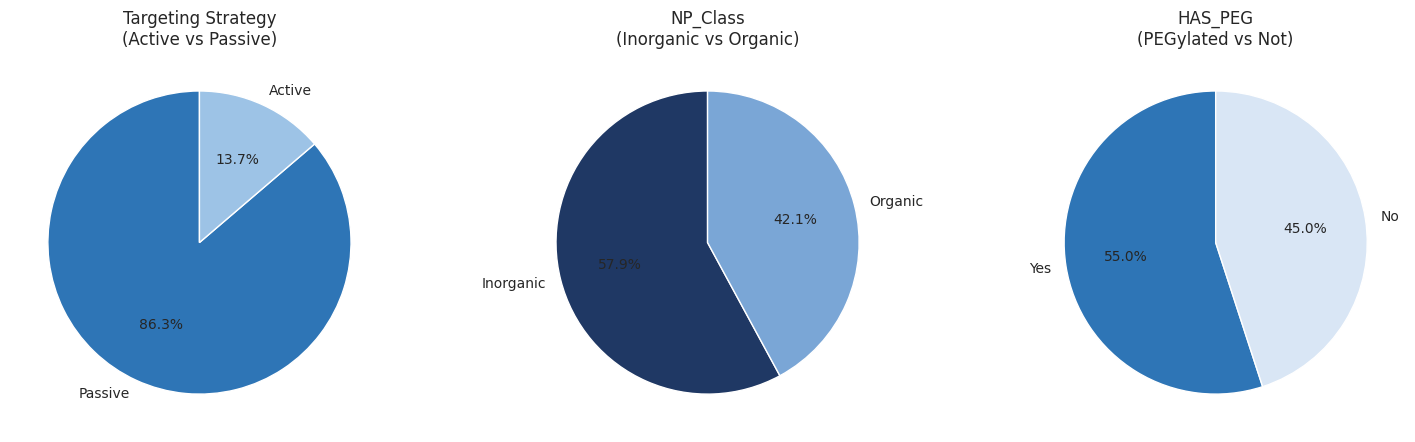

In [ ]:
# Pie charts: Targeting Strategy, NP_Class, HAS_PEG
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, col, title, colors in zip(
    axes,
    ['Targeting Strategy', 'NP_Class', 'HAS_PEG'],
    ['Targeting Strategy\n(Active vs Passive)',
     'NP_Class\n(Inorganic vs Organic)',
     'HAS_PEG\n(PEGylated vs Not)'],
    [['#2E75B6','#9DC3E6'],['#1F3864','#7AA6D6'],['#2E75B6','#D9E6F5']]
):
    counts = df[col].value_counts()
    ax.pie(counts, labels=counts.index, autopct='%1.1f%%',
           colors=colors, startangle=90)
    ax.set_title(title)

plt.tight_layout()
plt.show()

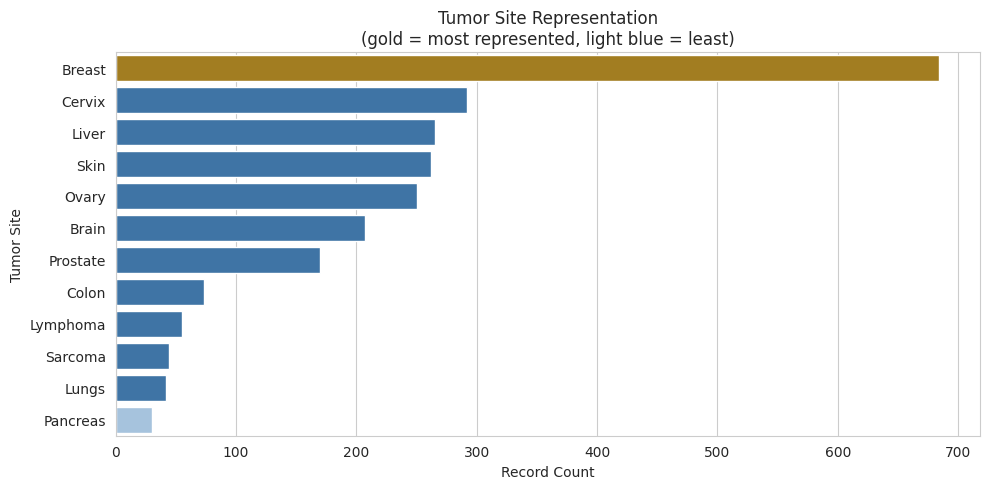

Tumor Site
Breast      684
Cervix      292
Liver       265
Skin        262
Ovary       250
Brain       207
Prostate    170
Colon        73
Lymphoma     55
Sarcoma      44
Lungs        42
Pancreas     30
Name: count, dtype: int64


In [ ]:
# Tumor Site representation imbalance
ts_counts = df['Tumor Site'].value_counts()

plt.figure(figsize=(10, 5))
colors = ['#B8860B' if c == ts_counts.max() else
          ('#9DC3E6' if c == ts_counts.min() else COLOR)
          for c in ts_counts.values]
sns.barplot(x=ts_counts.values, y=ts_counts.index, palette=colors, orient='h')
plt.xlabel('Record Count')
plt.title('Tumor Site Representation\n(gold = most represented, light blue = least)')
plt.tight_layout()
plt.show()
print(ts_counts)

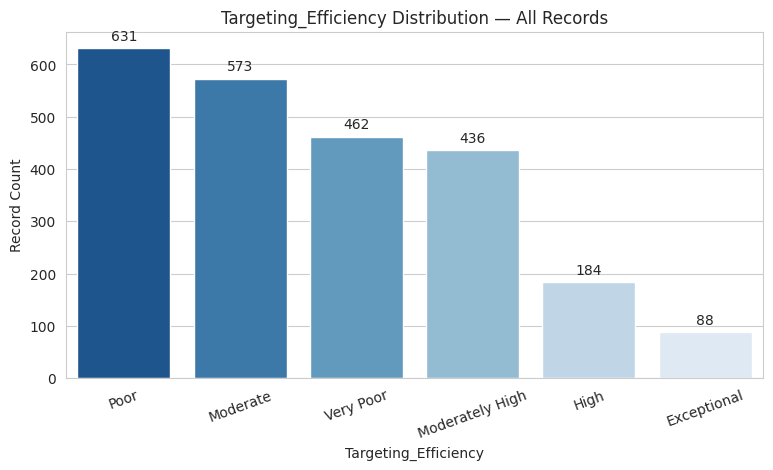

Targeting_Efficiency
Poor               631
Moderate           573
Very Poor          462
Moderately High    436
High               184
Exceptional         88
Name: count, dtype: int64

Exceptional ratio: 3.7% of all records


In [ ]:
te_counts = df['Targeting_Efficiency'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(9, 4.5))
sns.barplot(
    x=te_counts.index,
    y=te_counts.values,
    palette=PALETTE
)

plt.xticks(rotation=20)
plt.ylabel('Record Count')
plt.title('Targeting_Efficiency Distribution — All Records')

for i, v in enumerate(te_counts.values):
    plt.text(i, v + 15, str(v), ha='center')

plt.show()

exceptional_pct = (df['Targeting_Efficiency'] == 'Exceptional').mean() * 100

print(te_counts)
print(f"\nExceptional ratio: {exceptional_pct:.1f}% of all records")

---
## 2. Nanoparticle Physical Design Properties

How particle size, surface charge (Zeta Potential), shape, and core material relate to tumor uptake (`Tumor_%ID`).

In [ ]:
# Cards >> Size Category
exceptional = df[df['Targeting_Efficiency'] == 'Exceptional']

profile = {

    'Small %'         : round((exceptional['Size_Category'] == 'Small').mean() * 100, 1),
    'Optimal Range %' : round((exceptional['Size_Category'] == 'Optimal Range').mean() * 100, 1),
    'Large %'         : round((exceptional['Size_Category'] == 'Large').mean() * 100, 1),

}

for k, v in profile.items():
    print(f'{k:<20}: {v}%')

Small %             : 76.1%
Optimal Range %     : 12.5%
Large %             : 11.4%


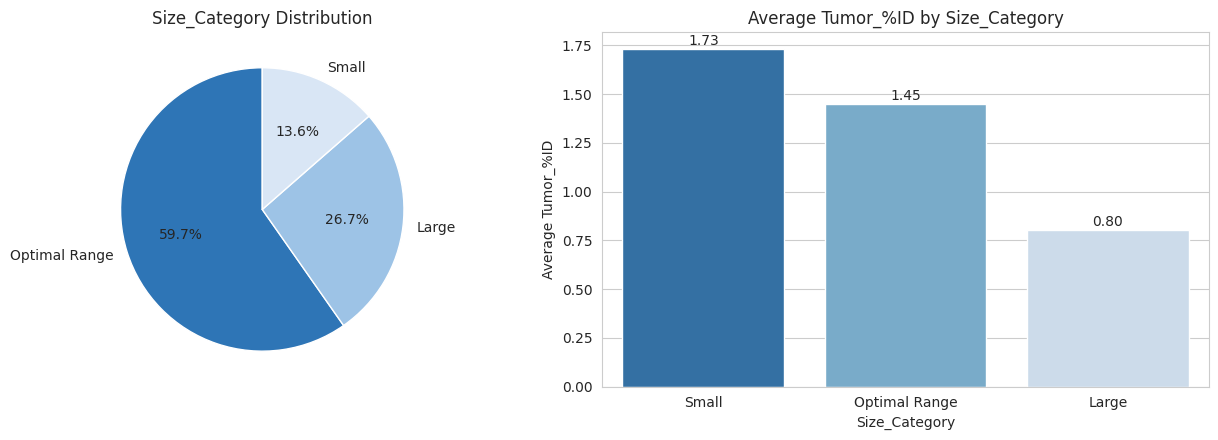

Size_Category
Small            1.73
Optimal Range    1.45
Large            0.80
Name: Tumor_%ID, dtype: float64


In [ ]:
# Size_Category distribution + avg Tumor_%ID per category
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

size_counts = df['Size_Category'].value_counts()
axes[0].pie(size_counts, labels=size_counts.index, autopct='%1.1f%%',
            colors=['#2E75B6','#9DC3E6','#D9E6F5'], startangle=90)
axes[0].set_title('Size_Category Distribution')

size_tumor = df.groupby('Size_Category')['Tumor_%ID'].mean().sort_values(ascending=False)
sns.barplot(x=size_tumor.index, y=size_tumor.values, ax=axes[1], palette=PALETTE)
axes[1].set_ylabel('Average Tumor_%ID')
axes[1].set_title('Average Tumor_%ID by Size_Category')
for i, v in enumerate(size_tumor.values):
    axes[1].text(i, v + 0.02, f'{v:.2f}', ha='center')

plt.tight_layout()
plt.show()
print(size_tumor.round(2))

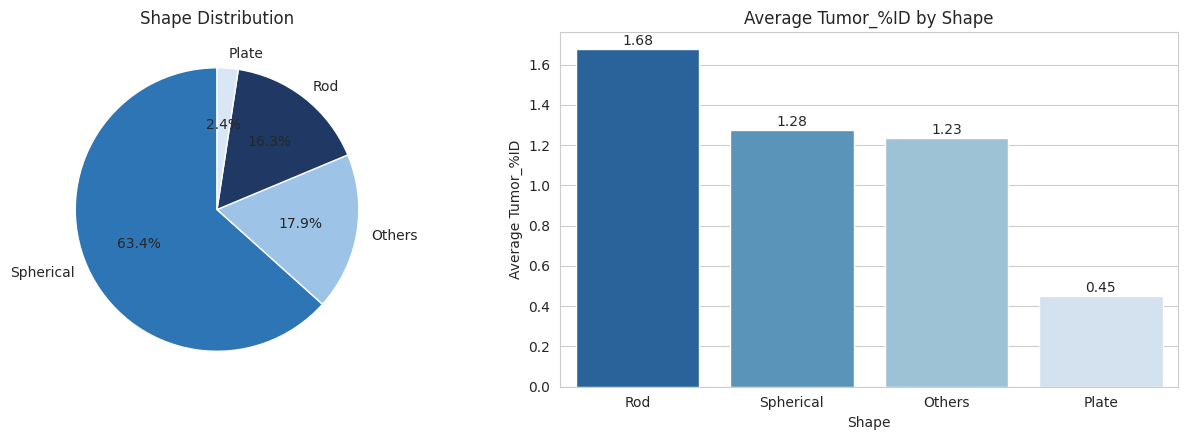

Shape
Rod          1.68
Spherical    1.28
Others       1.23
Plate        0.45
Name: Tumor_%ID, dtype: float64


In [ ]:
# Shape distribution + avg Tumor_%ID per shape
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

shape_counts = df['Shape'].value_counts()
axes[0].pie(shape_counts, labels=shape_counts.index, autopct='%1.1f%%',
            colors=['#2E75B6','#9DC3E6','#1F3864','#D9E6F5'], startangle=90)
axes[0].set_title('Shape Distribution')

shape_tumor = df.groupby('Shape')['Tumor_%ID'].mean().sort_values(ascending=False)
sns.barplot(x=shape_tumor.index, y=shape_tumor.values, ax=axes[1], palette=PALETTE)
axes[1].set_ylabel('Average Tumor_%ID')
axes[1].set_title('Average Tumor_%ID by Shape')
for i, v in enumerate(shape_tumor.values):
    axes[1].text(i, v + 0.02, f'{v:.2f}', ha='center')

plt.tight_layout()
plt.show()
print(shape_tumor.round(2))

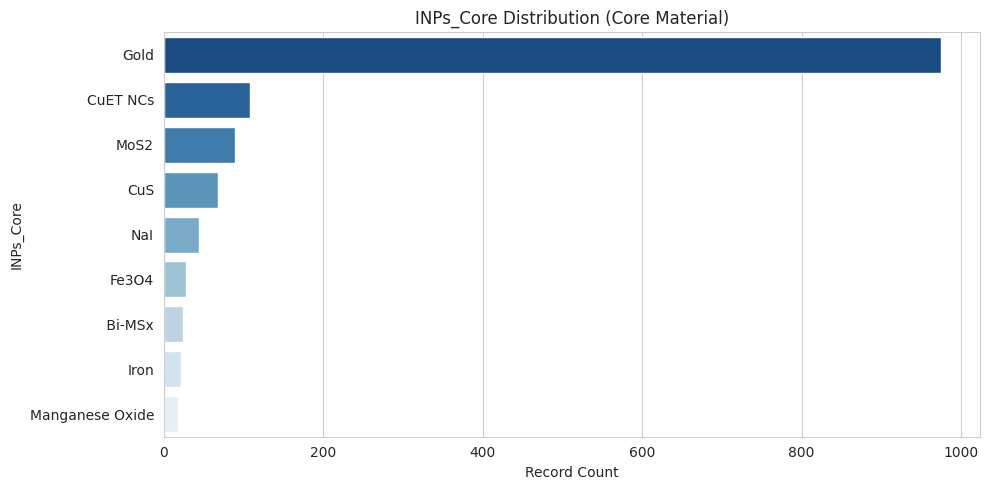

,Count,Avg_Tumor_%ID
INPs_Core,,
Gold,975,1.54
CuET NCs,108,0.14
MoS2,89,0.54
CuS,68,0.89
NaI,44,2.56
Fe3O4,28,0.25
Bi-MSx,24,0.43
Iron,21,1.05
Manganese Oxide,18,0.43


In [ ]:
df_core = df[df['INPs_Core'] != 'No_Core']

core_summary = pd.DataFrame({
    'Count': df_core['INPs_Core'].value_counts(),
    'Avg_Tumor_%ID': df_core.groupby('INPs_Core')['Tumor_%ID'].mean().round(2)
}).sort_values('Count', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(
    x=core_summary['Count'].values,
    y=core_summary.index,
    palette=PALETTE,
    orient='h'
)

plt.xlabel('Record Count')
plt.title('INPs_Core Distribution (Core Material)')
plt.tight_layout()
plt.show()

core_summary

## 3 Zeta Potential — Dedicated Analysis

Zeta Potential has a high missing-value rate (**25.7% of records**).
All Zeta-related charts below are built **only on the 1,763 records that do have a recorded value** — the 611 missing rows are excluded for this section only.

In [ ]:
df_zeta = df.dropna(subset=['Zeta Potential (mv)', 'Zeta_Category']).copy()

print(f"Full dataset         : {len(df):,} records")
print(f"Missing Zeta values  : {df['Zeta Potential (mv)'].isna().sum():,}  "
      f"({df['Zeta Potential (mv)'].isna().sum()/len(df)*100:.1f}%) — excluded below")
print(f"Zeta subset (df_zeta): {len(df_zeta):,} records used for every chart in this section")

##df_zeta.head()

Full dataset         : 2,374 records
Missing Zeta values  : 611  (25.7%) — excluded below
Zeta subset (df_zeta): 1,763 records used for every chart in this section


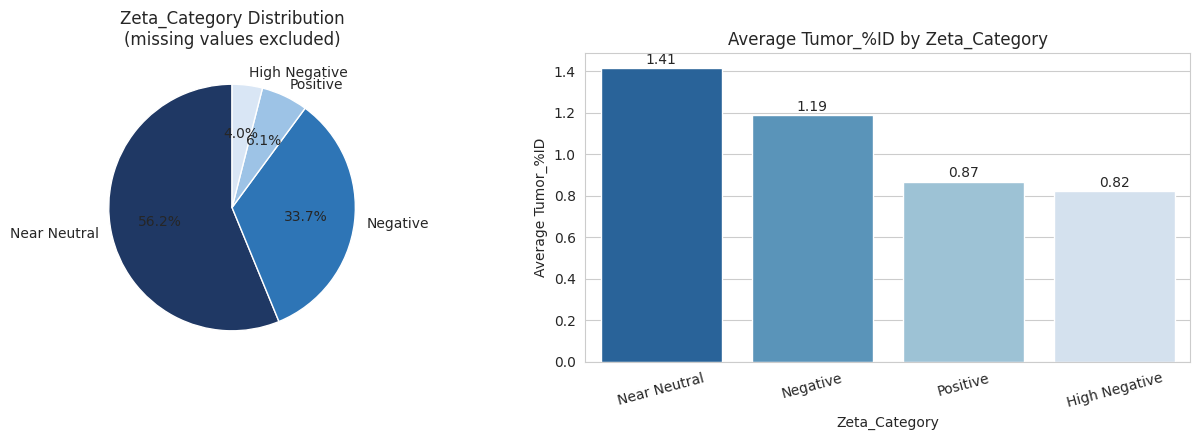

Zeta_Category
Near Neutral     1.41
Negative         1.19
Positive         0.87
High Negative    0.82
Name: Tumor_%ID, dtype: float64


In [ ]:
# Zeta_Category distribution + avg Tumor_%ID (Zeta subset only)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

zeta_counts = df_zeta['Zeta_Category'].value_counts()
axes[0].pie(zeta_counts, labels=zeta_counts.index, autopct='%1.1f%%',
            colors=['#1F3864','#2E75B6','#9DC3E6','#D9E6F5'], startangle=90)
axes[0].set_title('Zeta_Category Distribution\n(missing values excluded)')

zeta_tumor = df_zeta.groupby('Zeta_Category')['Tumor_%ID'].mean().sort_values(ascending=False)
sns.barplot(x=zeta_tumor.index, y=zeta_tumor.values, ax=axes[1], palette=PALETTE)
axes[1].set_ylabel('Average Tumor_%ID')
axes[1].set_title('Average Tumor_%ID by Zeta_Category')
axes[1].tick_params(axis='x', rotation=15)
for i, v in enumerate(zeta_tumor.values):
    axes[1].text(i, v + 0.02, f'{v:.2f}', ha='center')

plt.tight_layout()
plt.show()
print(zeta_tumor.round(2))

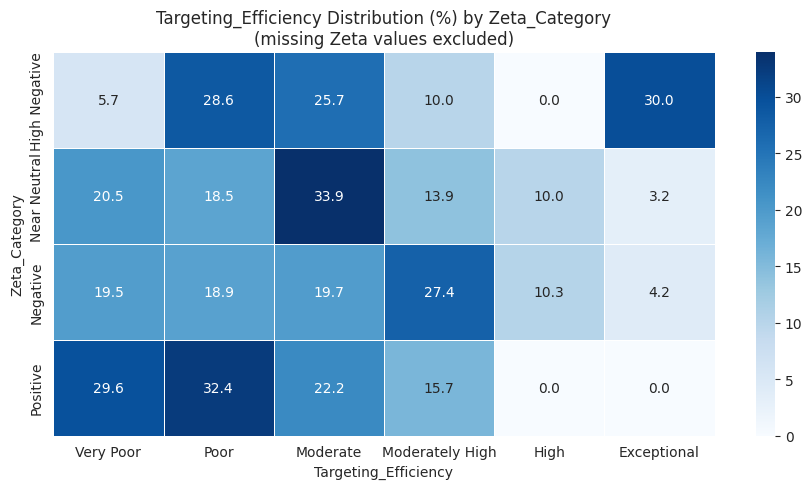

In [ ]:
# Heatmap: Targeting_Efficiency (%) by Zeta_Category
EFFICIENCY_ORDER = ['Very Poor','Poor','Moderate','Moderately High','High','Exceptional']

ct_zeta_eff = pd.crosstab(df_zeta['Zeta_Category'],
                           df_zeta['Targeting_Efficiency'],
                           normalize='index')[EFFICIENCY_ORDER] * 100

plt.figure(figsize=(9, 5))
sns.heatmap(ct_zeta_eff, annot=True, fmt='.1f', cmap='Blues', linewidths=0.5)
plt.title('Targeting_Efficiency Distribution (%) by Zeta_Category\n(missing Zeta values excluded)')
plt.tight_layout()
plt.show()

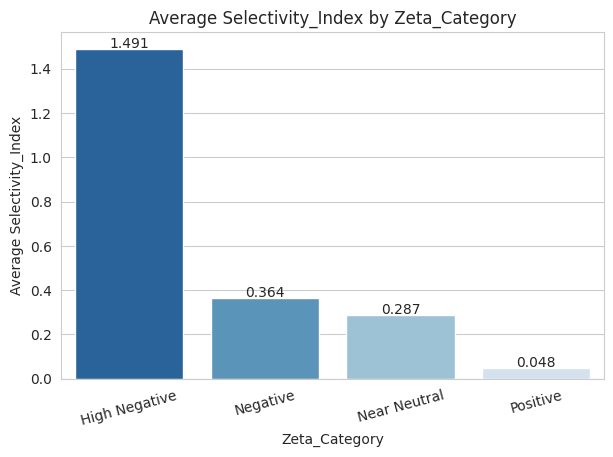

Zeta_Category
High Negative    1.4910
Negative         0.3640
Near Neutral     0.2870
Positive         0.0483
Name: Selectivity_Index, dtype: float64


In [ ]:
# Avg Selectivity_Index by Zeta_Category
zeta_sel = df_zeta.groupby('Zeta_Category')['Selectivity_Index'].mean().sort_values(ascending=False)

plt.figure(figsize=(7, 4.5))
sns.barplot(x=zeta_sel.index, y=zeta_sel.values, palette=PALETTE)
plt.ylabel('Average Selectivity_Index')
plt.title('Average Selectivity_Index by Zeta_Category')
plt.xticks(rotation=15)
for i, v in enumerate(zeta_sel.values):
    plt.text(i, v + 0.005, f'{v:.3f}', ha='center')
plt.show()
print(zeta_sel.round(4))

---
## 4. Targeting Strategy Performance

Comparing Active vs. Passive targeting across tumor uptake, efficiency, and selectivity.

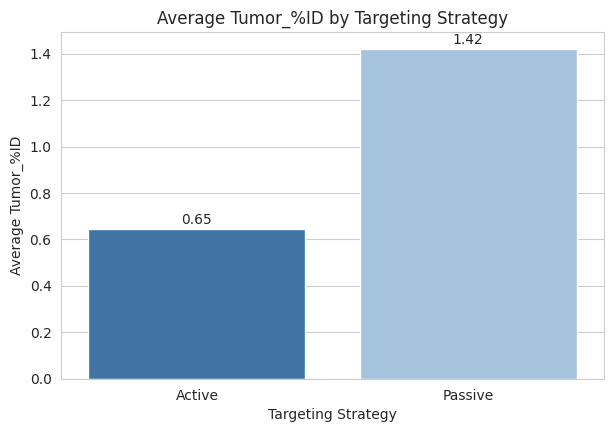

Targeting Strategy
Active     0.65
Passive    1.42
Name: Tumor_%ID, dtype: float64


In [ ]:
# Avg Tumor_%ID by Targeting Strategy
ts_tumor = df.groupby('Targeting Strategy')['Tumor_%ID'].mean()

plt.figure(figsize=(7, 4.5))
sns.barplot(x=ts_tumor.index, y=ts_tumor.values, palette=['#2E75B6','#9DC3E6'])
plt.ylabel('Average Tumor_%ID')
plt.title('Average Tumor_%ID by Targeting Strategy')
for i, v in enumerate(ts_tumor.values):
    plt.text(i, v + 0.02, f'{v:.2f}', ha='center')
plt.show()
print(ts_tumor.round(2))

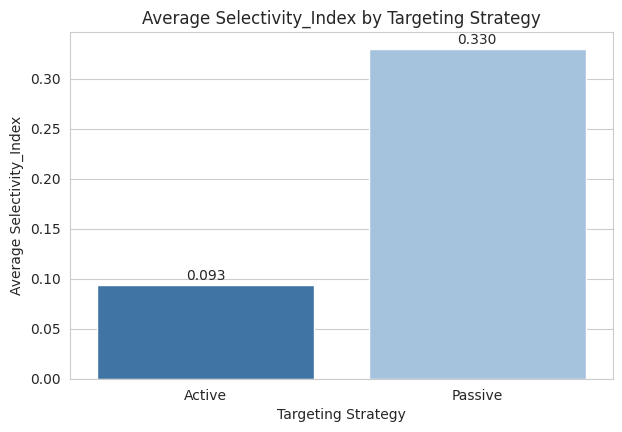

Targeting Strategy
Active     0.0934
Passive    0.3298
Name: Selectivity_Index, dtype: float64


In [ ]:
# Avg Selectivity_Index by Targeting Strategy
ts_sel = df.groupby('Targeting Strategy')['Selectivity_Index'].mean()

plt.figure(figsize=(7, 4.5))
sns.barplot(x=ts_sel.index, y=ts_sel.values, palette=['#2E75B6','#9DC3E6'])
plt.ylabel('Average Selectivity_Index')
plt.title('Average Selectivity_Index by Targeting Strategy')
for i, v in enumerate(ts_sel.values):
    plt.text(i, v + 0.005, f'{v:.3f}', ha='center')
plt.show()
print(ts_sel.round(4))

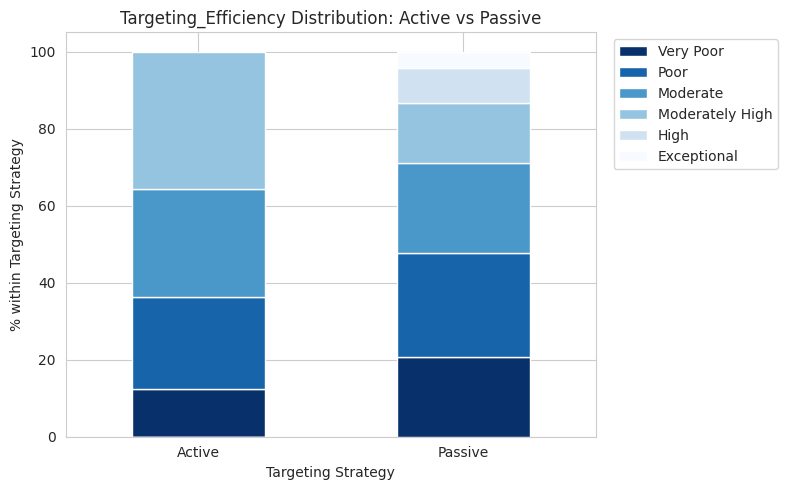

Targeting_Efficiency,Very Poor,Poor,Moderate,Moderately High,High,Exceptional
Targeting Strategy,,,,,,
Active,12.3,23.9,28.2,35.6,0.0,0.0
Passive,20.6,27.0,23.5,15.6,9.0,4.3


In [ ]:
# 100% stacked bar: Targeting Strategy x Targeting_Efficiency
ct = pd.crosstab(df['Targeting Strategy'],
                 df['Targeting_Efficiency'],
                 normalize='index')[EFFICIENCY_ORDER] * 100

ct.plot(kind='bar', stacked=True, figsize=(8, 5), colormap='Blues_r')
plt.ylabel('% within Targeting Strategy')
plt.title('Targeting_Efficiency Distribution: Active vs Passive')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
ct.round(1)

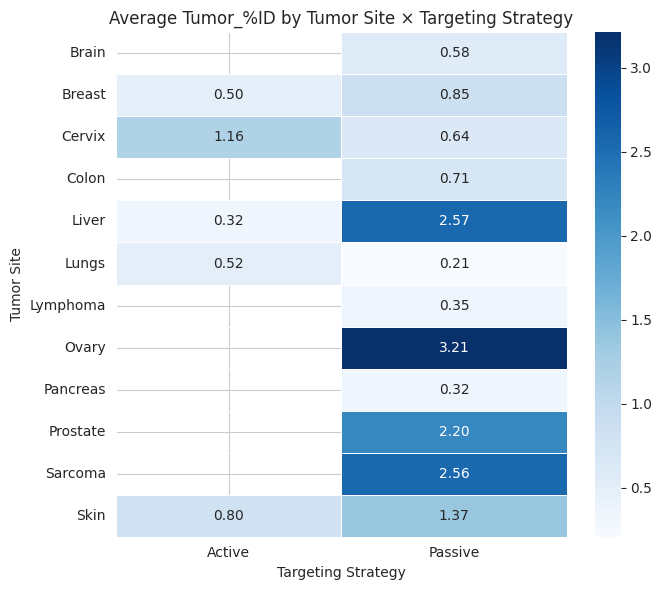

In [ ]:
# Heatmap: Tumor Site x Targeting Strategy → Avg Tumor_%ID
pivot = df.pivot_table(index='Tumor Site', columns='Targeting Strategy',
                       values='Tumor_%ID', aggfunc='mean')

plt.figure(figsize=(7, 6))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='Blues', linewidths=0.5)
plt.title('Average Tumor_%ID by Tumor Site × Targeting Strategy')
plt.tight_layout()
plt.show()

---
## 5. Tumor Biology & Organ Targeting

Where biodistribution concentrates — by tumor site, tumor cell line, and organ/tissue.

In [45]:
# Cards for Organ Page
unique_organs      = df['Organ or tissue'].nunique()
unique_tumor_sites = df['Tumor Site'].nunique()
unique_cells        = df['Tumor Cell'].str.strip().nunique()   # ← إضافة .str.strip() هنا

print(f"Unique Organs measured             : {unique_organs}")
print(f"Unique Tumor Cell lines            : {unique_cells}")

Unique Organs measured             : 17
Unique Tumor Cell lines            : 31


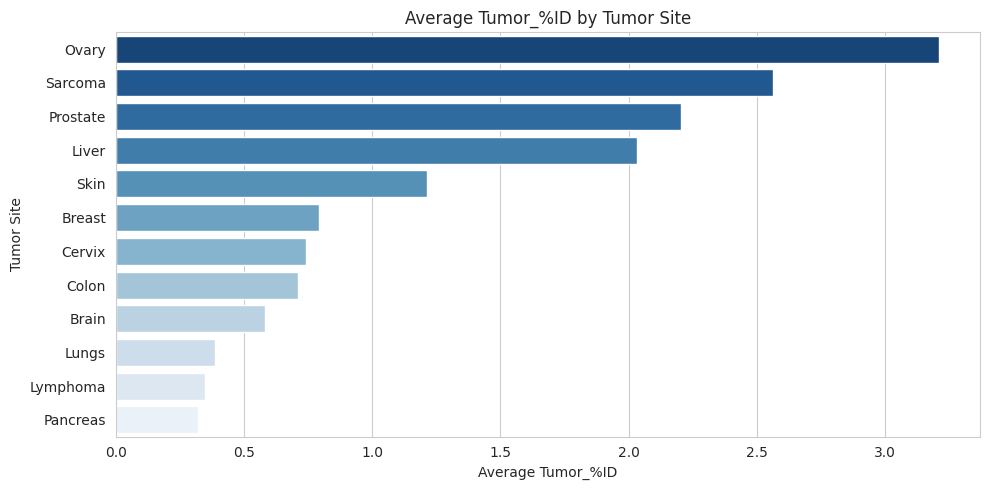

,Tumor_%ID
Tumor Site,
Ovary,3.21
Sarcoma,2.56
Prostate,2.20
Liver,2.03
Skin,1.21
Breast,0.79
Cervix,0.74
Colon,0.71
Brain,0.58


In [ ]:
# Avg Tumor_%ID by Tumor Site
site_tumor = df.groupby('Tumor Site')['Tumor_%ID'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=site_tumor.values, y=site_tumor.index, palette=PALETTE, orient='h')
plt.xlabel('Average Tumor_%ID')
plt.title('Average Tumor_%ID by Tumor Site')
plt.tight_layout()
plt.show()
site_tumor.round(2)

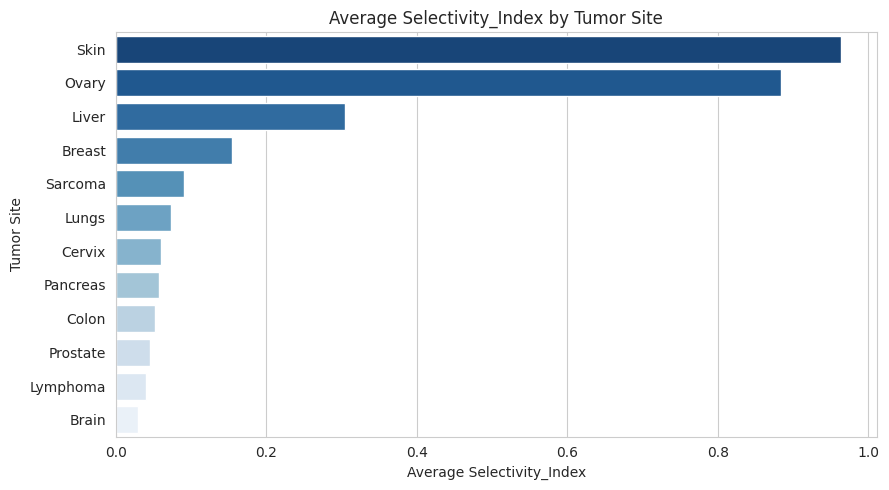

,Selectivity_Index
Tumor Site,
Skin,0.964
Ovary,0.884
Liver,0.304
Breast,0.155
Sarcoma,0.091
Lungs,0.073
Cervix,0.059
Pancreas,0.057
Colon,0.052


In [ ]:
# Avg Selectivity_Index by Tumor Site
site_sel = df.groupby('Tumor Site')['Selectivity_Index'].mean().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(x=site_sel.values, y=site_sel.index, palette=PALETTE, orient='h')
plt.xlabel('Average Selectivity_Index')
plt.title('Average Selectivity_Index by Tumor Site')
plt.tight_layout()
plt.show()
site_sel.round(3)

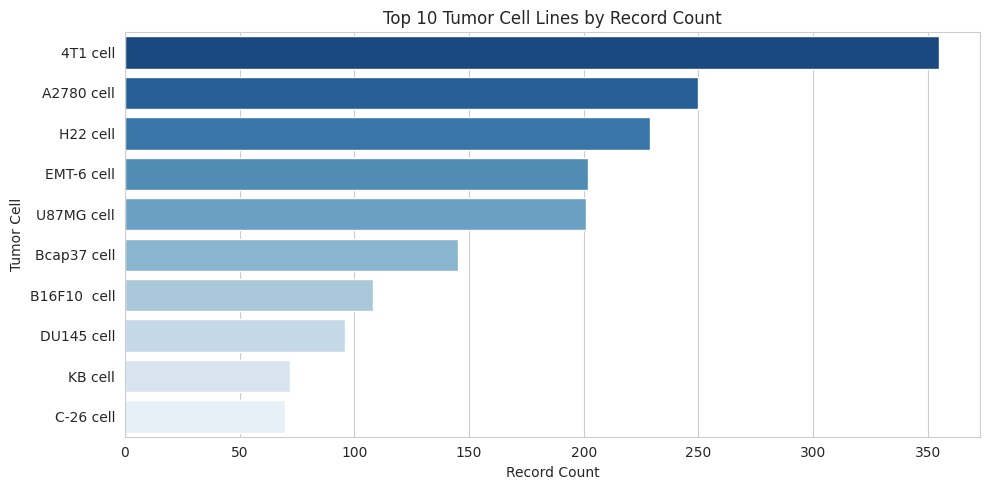

,count
Tumor Cell,
4T1 cell,355
A2780 cell,250
H22 cell,229
EMT-6 cell,202
U87MG cell,201
Bcap37 cell,145
B16F10 cell,108
DU145 cell,96
KB cell,72


In [ ]:
# Top 10 Tumor Cell Lines
tc_counts = df['Tumor Cell'].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=tc_counts.values, y=tc_counts.index, palette=PALETTE, orient='h')
plt.xlabel('Record Count')
plt.title('Top 10 Tumor Cell Lines by Record Count')
plt.tight_layout()
plt.show()
tc_counts

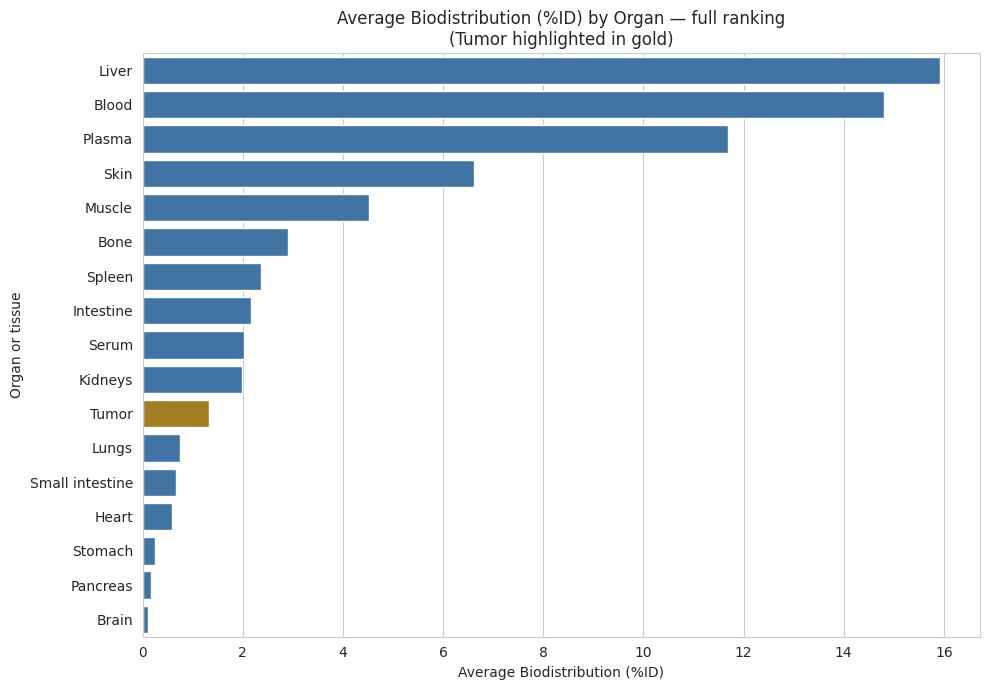

,Organ or tissue,Avg Biodistribution (%ID)
1,Liver,15.925079
2,Blood,14.812572
3,Plasma,11.683386
4,Skin,6.618422
5,Muscle,4.525077
6,Bone,2.892771
7,Spleen,2.361499
8,Intestine,2.171137
9,Serum,2.019222
10,Kidneys,1.975181


In [ ]:
# Avg Biodistribution (%ID) by Organ — full ranking (Tumor highlighted)
organ_rank = df.groupby('Organ or tissue')['Biodistribution (%ID)'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 7))
colors = ['#B8860B' if o == 'Tumor' else COLOR for o in organ_rank.index]
sns.barplot(x=organ_rank.values, y=organ_rank.index, palette=colors, orient='h')
plt.xlabel('Average Biodistribution (%ID)')
plt.title('Average Biodistribution (%ID) by Organ — full ranking\n(Tumor highlighted in gold)')
plt.tight_layout()
plt.show()

tbl = organ_rank.reset_index()
tbl.index = tbl.index + 1
tbl.columns = ['Organ or tissue', 'Avg Biodistribution (%ID)']
tbl

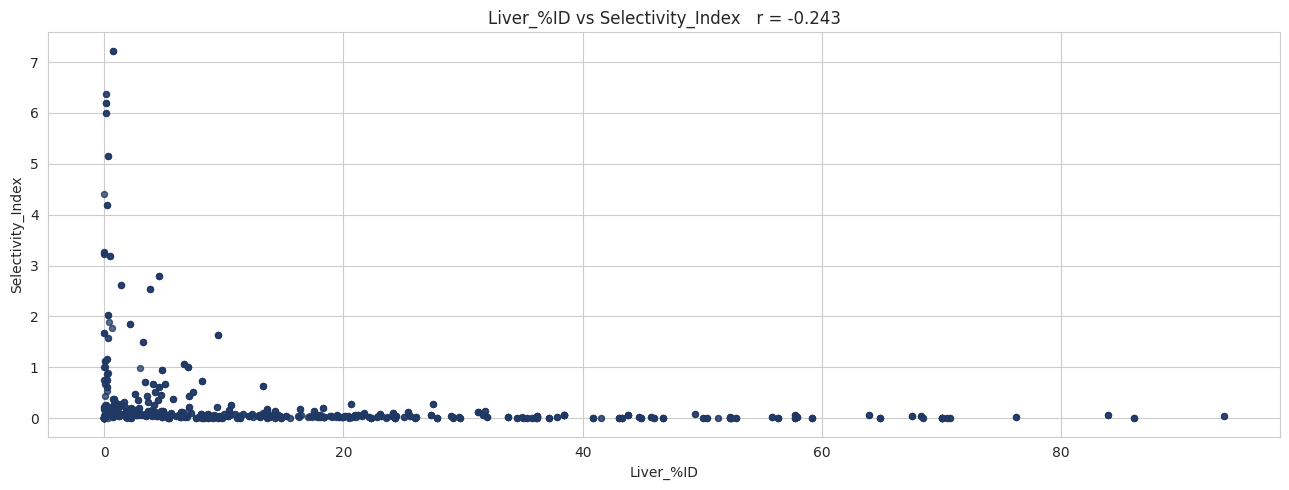

In [ ]:
fig, ax = plt.subplots(figsize=(13, 5))

ax.scatter(
    df['Liver_%ID'],
    df['Selectivity_Index'],
    alpha=0.35,
    color='#1F3864',
    s=18
)

ax.set_xlabel('Liver_%ID')
ax.set_ylabel('Selectivity_Index')

corr_ls = df['Liver_%ID'].corr(df['Selectivity_Index'])

ax.set_title(
    f'Liver_%ID vs Selectivity_Index   r = {corr_ls:.3f}'
)

plt.tight_layout()
plt.show()

In [ ]:
# Brain biodistribution (lowest organ)
brain = df[df['Organ or tissue'] == 'Brain']['Biodistribution (%ID)']
print(f"Brain — Avg Biodistribution (%ID): {brain.mean():.3f}  (n = {len(brain)} records)")

Brain — Avg Biodistribution (%ID): 0.108  (n = 52 records)


---
## 6. Surface Coating & Shell Analysis (PEG page)

How the shell (coating) material relates to tumor uptake and selectivity, and the specific effect of PEGylation.

In [ ]:
# # Kpi "Cards" >> PEG page
profile = {

    'PEG %'              : round((df['HAS_PEG'] == 'Yes').mean() * 100, 1),

    'No Stealth Effect %': round((df['Shell Type'] == 'No Stealth Effect').mean() * 100, 1),

    'HPMA %'             : round((df['Shell Type'] == 'HPMA').mean() * 100, 1),

    'Cellulose %'        : round((df['Shell Type'] == 'Cellulose').mean() * 100, 1),

}

for k, v in profile.items():
    print(f'{k:<26}: {v}%')

PEG %                     : 55.0%
No Stealth Effect %       : 29.6%
HPMA %                    : 4.8%
Cellulose %               : 2.6%


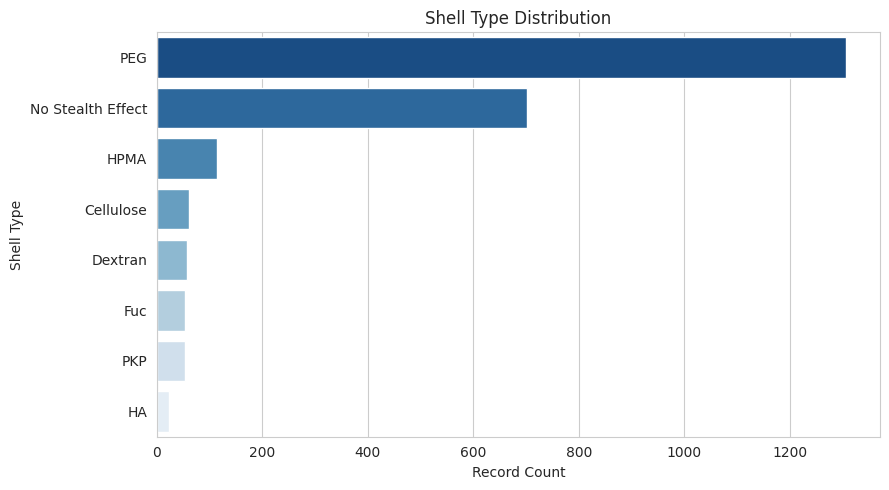

,Count,Pct
Shell Type,,
PEG,1306,55.0
No Stealth Effect,702,29.6
HPMA,115,4.8
Cellulose,62,2.6
Dextran,57,2.4
Fuc,54,2.3
PKP,54,2.3
HA,24,1.0


In [ ]:
# Shell Type distribution
shell_counts = df['Shell Type'].value_counts()

plt.figure(figsize=(9, 5))
sns.barplot(x=shell_counts.values, y=shell_counts.index, palette=PALETTE, orient='h')
plt.xlabel('Record Count')
plt.title('Shell Type Distribution')
plt.tight_layout()
plt.show()
(shell_counts.to_frame('Count')
             .assign(Pct=lambda d: (d['Count']/len(df)*100).round(1)))

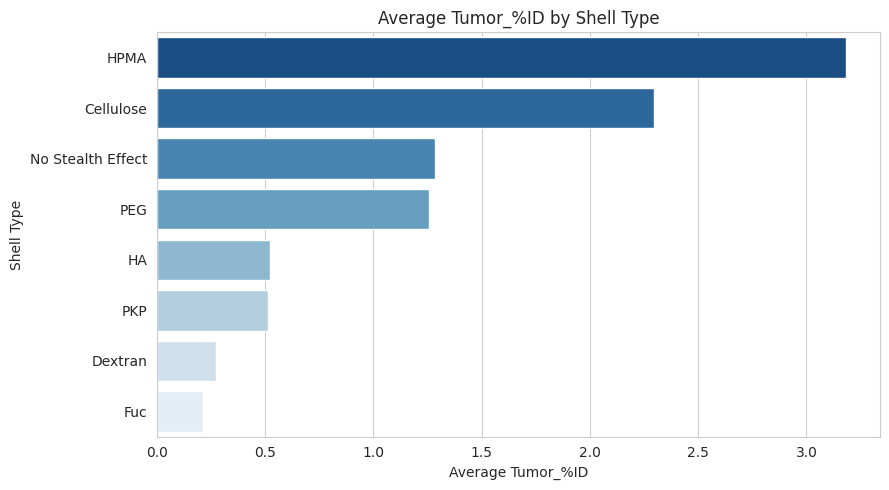

,Tumor_%ID
Shell Type,
HPMA,3.18
Cellulose,2.29
No Stealth Effect,1.29
PEG,1.26
HA,0.52
PKP,0.51
Dextran,0.28
Fuc,0.21


In [ ]:
# Avg Tumor_%ID by Shell Type
shell_tumor = df.groupby('Shell Type')['Tumor_%ID'].mean().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(x=shell_tumor.values, y=shell_tumor.index, palette=PALETTE, orient='h')
plt.xlabel('Average Tumor_%ID')
plt.title('Average Tumor_%ID by Shell Type')
plt.tight_layout()
plt.show()
shell_tumor.round(2)

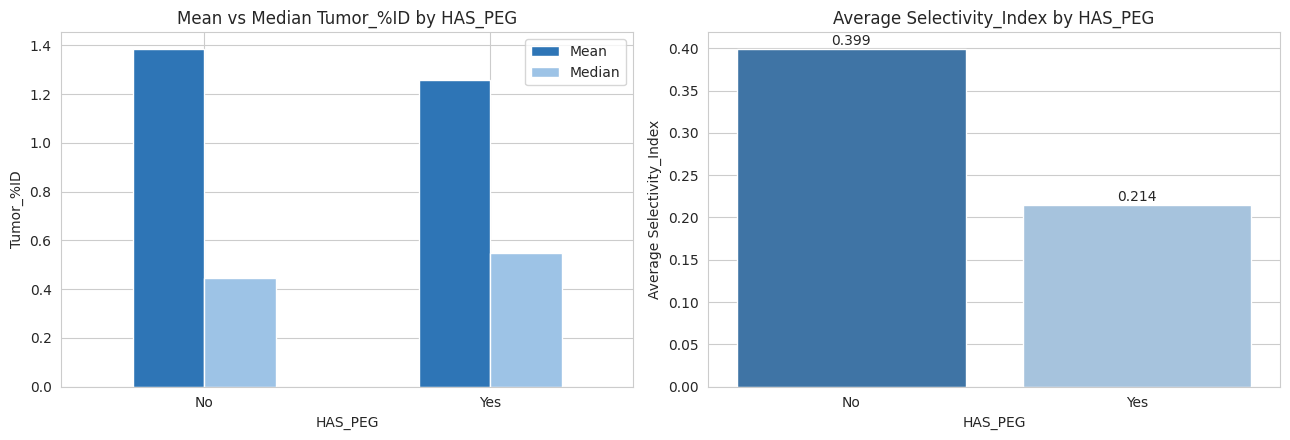

          mean  median
HAS_PEG               
No       1.384   0.445
Yes      1.259   0.550

HAS_PEG
No     0.3988
Yes    0.2143
Name: Selectivity_Index, dtype: float64


In [ ]:
# HAS_PEG → mean/median Tumor_%ID and Avg Selectivity_Index
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

peg_stats = df.groupby('HAS_PEG')['Tumor_%ID'].agg(['mean','median'])
peg_stats.plot(kind='bar', ax=axes[0], color=['#2E75B6','#9DC3E6'])
axes[0].set_ylabel('Tumor_%ID')
axes[0].set_title('Mean vs Median Tumor_%ID by HAS_PEG')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(['Mean','Median'])

peg_sel = df.groupby('HAS_PEG')['Selectivity_Index'].mean()
sns.barplot(x=peg_sel.index, y=peg_sel.values, ax=axes[1], palette=['#2E75B6','#9DC3E6'])
axes[1].set_ylabel('Average Selectivity_Index')
axes[1].set_title('Average Selectivity_Index by HAS_PEG')
for i, v in enumerate(peg_sel.values):
    axes[1].text(i, v + 0.005, f'{v:.3f}', ha='center')

plt.tight_layout()
plt.show()
print(peg_stats.round(3)); print(); print(peg_sel.round(4))

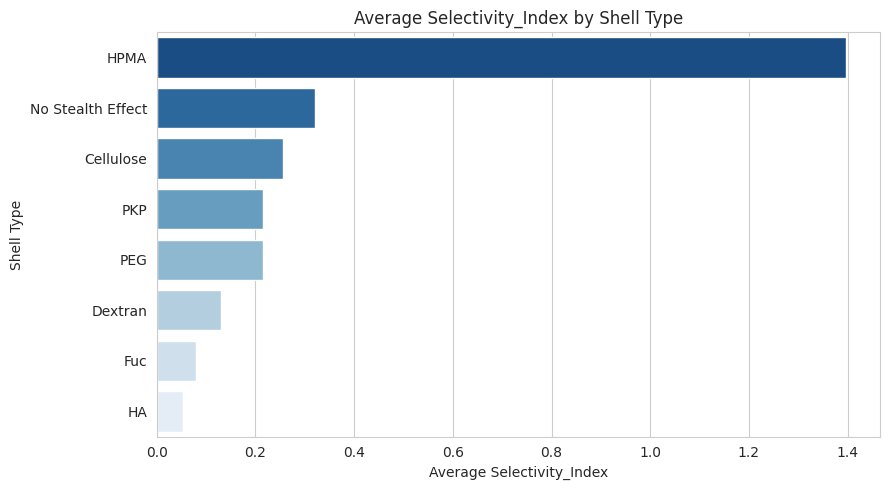

,Selectivity_Index
Shell Type,
HPMA,1.3959
No Stealth Effect,0.3204
Cellulose,0.2562
PKP,0.2152
PEG,0.2143
Dextran,0.1309
Fuc,0.0802
HA,0.0523


In [ ]:
# Avg Selectivity_Index by Shell Type
shell_sel = (
    df.groupby('Shell Type')['Selectivity_Index']
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))
sns.barplot(
    x=shell_sel.values,
    y=shell_sel.index,
    palette=PALETTE,
    orient='h'
)

plt.xlabel('Average Selectivity_Index')
plt.title('Average Selectivity_Index by Shell Type')
plt.tight_layout()
plt.show()

shell_sel.round(4)

---
## 7. Time Point & Dosage Analysis

How tumor and liver/spleen uptake evolve over time, and how dosage relates to biodistribution.

In [ ]:
# Time_Phase distribution
phase_counts = df['Time_Phase'].value_counts()
print(phase_counts)
print()
phase_pct = (phase_counts / len(df) * 100).round(1)
print(phase_pct)

Time_Phase
Early           2060
Intermediate     238
Late              76
Name: count, dtype: int64

Time_Phase
Early           86.8
Intermediate    10.0
Late             3.2
Name: count, dtype: float64


In [ ]:
import plotly.graph_objects as go

dual = df.groupby('Time point (h)')[['Liver_%ID', 'Tumor_%ID', 'Spleen_%ID']].mean().sort_index()

peak_t = dual['Tumor_%ID'].idxmax()
peak_val = dual['Tumor_%ID'].max()

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=dual.index,
        y=dual['Liver_%ID'],
        mode='lines+markers',
        name='Liver_%ID',
        yaxis='y1'
    )
)

fig.add_trace(
    go.Scatter(
        x=dual.index,
        y=dual['Spleen_%ID'],
        mode='lines+markers',
        name='Spleen_%ID',
        yaxis='y1'
    )
)

fig.add_trace(
    go.Scatter(
        x=dual.index,
        y=dual['Tumor_%ID'],
        mode='lines+markers',
        name='Tumor_%ID',
        yaxis='y2'
    )
)

fig.add_vline(
    x=peak_t,
    line_dash="dash",
    annotation_text=f"Peak Tumor ({peak_t}h)"
)

fig.update_layout(
    title='Liver_%ID vs Tumor_%ID vs Spleen_%ID Across Time Points',
    xaxis_title='Time point (h)',

    yaxis=dict(
        title='Average Liver/Spleen_%ID'
    ),

    yaxis2=dict(
        title='Average Tumor_%ID',
        overlaying='y',
        side='right'
    ),

    hovermode='x unified',
    width=1000,
    height=550
)

fig.show()

print(f"Peak avg Tumor_%ID at {peak_t}h → {peak_val:.2f} %ID")

Peak avg Tumor_%ID at 15.0h → 4.16 %ID


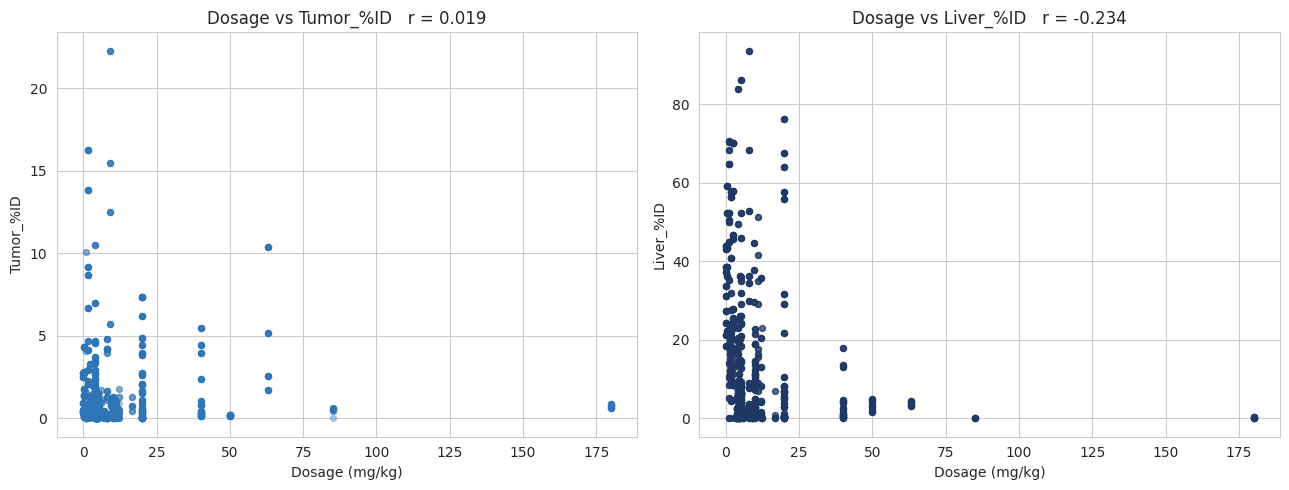

In [ ]:
# Scatter: Dosage vs Tumor_%ID and Dosage vs Liver_%ID
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(df['Administration Dosages (mg/kg)'], df['Tumor_%ID'],
                alpha=0.35, color=COLOR, s=18)
axes[0].set_xlabel('Dosage (mg/kg)'); axes[0].set_ylabel('Tumor_%ID')
corr_dt = df['Administration Dosages (mg/kg)'].corr(df['Tumor_%ID'])
axes[0].set_title(f'Dosage vs Tumor_%ID   r = {corr_dt:.3f}')

axes[1].scatter(df['Administration Dosages (mg/kg)'], df['Liver_%ID'],
                alpha=0.35, color='#1F3864', s=18)
axes[1].set_xlabel('Dosage (mg/kg)'); axes[1].set_ylabel('Liver_%ID')
corr_dl = df['Administration Dosages (mg/kg)'].corr(df['Liver_%ID'])
axes[1].set_title(f'Dosage vs Liver_%ID   r = {corr_dl:.3f}')

plt.tight_layout()
plt.show()

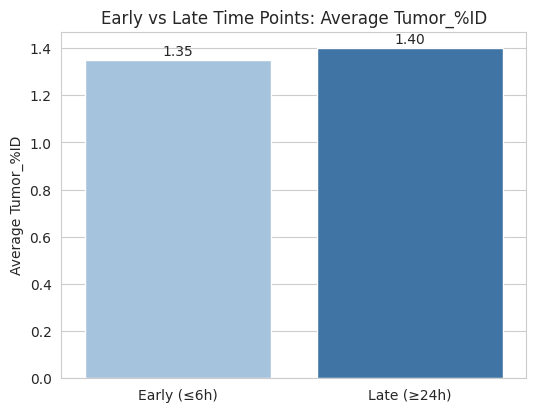

Early (≤6h): 1.35 %ID   |   Late (≥24h): 1.40 %ID


In [ ]:
# Early (≤6h) vs Late (≥24h) Tumor_%ID
early = df[df['Time point (h)'] <= 6]['Tumor_%ID'].mean()
late  = df[df['Time point (h)'] >= 24]['Tumor_%ID'].mean()

plt.figure(figsize=(6, 4.5))
sns.barplot(x=['Early (≤6h)','Late (≥24h)'], y=[early, late ],
            palette=['#9DC3E6','#2E75B6'])
plt.ylabel('Average Tumor_%ID')
plt.title('Early vs Late Time Points: Average Tumor_%ID')
for i, v in enumerate([early, late]):
    plt.text(i, v + 0.02, f'{v:.2f}', ha='center')
plt.show()
print(f"Early (≤6h): {early:.2f} %ID   |   Late (≥24h): {late:.2f} %ID")

---
## 8. Responsive Release Mechanisms

How stimulus-responsive release (pH, GSH, Heat, Light, Dual, or None) relates to tumor uptake, selectivity, and targeting efficiency.

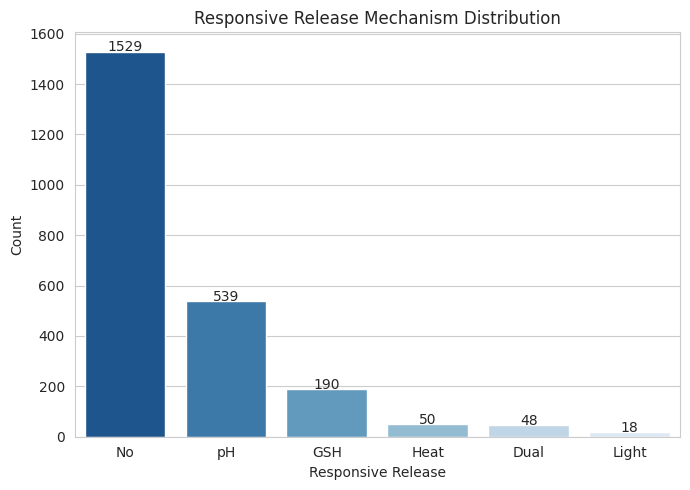

Responsive release
No       1529
pH        539
GSH       190
Heat       50
Dual       48
Light      18
Name: count, dtype: int64


In [ ]:
# Responsive release distribution (Bar Chart)
rr_counts = df['Responsive release'].value_counts()

plt.figure(figsize=(7, 5))
sns.barplot(
    x=rr_counts.index,
    y=rr_counts.values,
    palette='Blues_r'
)

plt.title('Responsive Release Mechanism Distribution')
plt.xlabel('Responsive Release')
plt.ylabel('Count')

# Display count on top of each bar
for i, v in enumerate(rr_counts.values):
    plt.text(i, v + 0.5, str(v), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print(rr_counts)

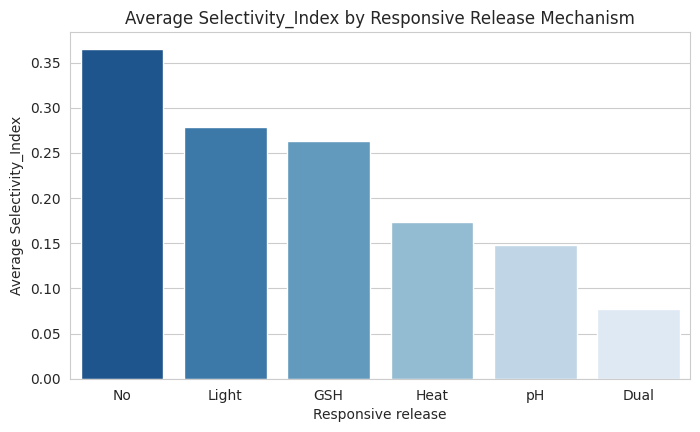

Responsive release
No       0.3653
Light    0.2784
GSH      0.2635
Heat     0.1735
pH       0.1482
Dual     0.0771
Name: Selectivity_Index, dtype: float64


In [ ]:
# Avg Selectivity_Index by Responsive release
rr_sel = df.groupby('Responsive release')['Selectivity_Index'].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 4.5))
sns.barplot(x=rr_sel.index, y=rr_sel.values, palette=PALETTE)
plt.ylabel('Average Selectivity_Index')
plt.title('Average Selectivity_Index by Responsive Release Mechanism')
plt.show()
print(rr_sel.round(4))

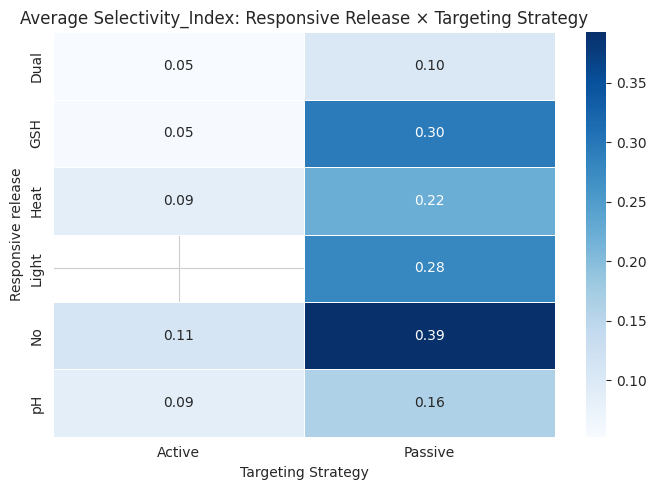

In [ ]:
# Heatmap: Responsive release × Targeting Strategy → Avg Tumor_%ID
pivot77 = df.pivot_table(index='Responsive release', columns='Targeting Strategy',
                         values='Selectivity_Index', aggfunc='mean')

plt.figure(figsize=(7, 5))
sns.heatmap(pivot77, annot=True, fmt='.2f', cmap='Blues', linewidths=0.5)
plt.title('Average Selectivity_Index: Responsive Release × Targeting Strategy')
plt.tight_layout()
plt.show()

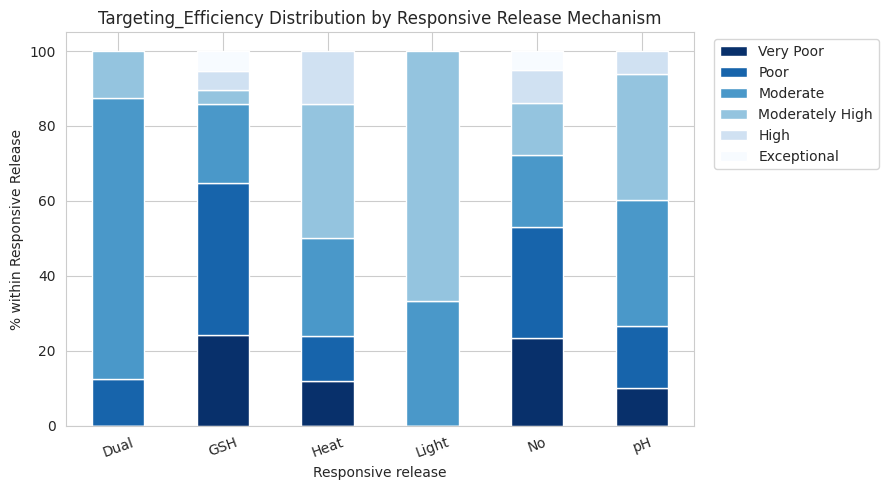

Targeting_Efficiency,Very Poor,Poor,Moderate,Moderately High,High,Exceptional
Responsive release,,,,,,
Dual,0.0,12.5,75.0,12.5,0.0,0.0
GSH,24.2,40.5,21.1,3.7,5.3,5.3
Heat,12.0,12.0,26.0,36.0,14.0,0.0
Light,0.0,0.0,33.3,66.7,0.0,0.0
No,23.3,29.6,19.4,13.8,8.8,5.1
pH,10.0,16.5,33.6,33.8,6.1,0.0


In [ ]:
# 100% stacked: Targeting_Efficiency by Responsive release
ct79 = pd.crosstab(df['Responsive release'],
                   df['Targeting_Efficiency'],
                   normalize='index')[EFFICIENCY_ORDER] * 100

ct79.plot(kind='bar', stacked=True, figsize=(9, 5), colormap='Blues_r')
plt.ylabel('% within Responsive Release')
plt.title('Targeting_Efficiency Distribution by Responsive Release Mechanism')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()
ct79.round(1)

---
## 9. Inorganic vs. Organic NPs Comparison

Comparing the two main nanoparticle classes across size, tumor site preference, liver/spleen accumulation, and release mechanisms.

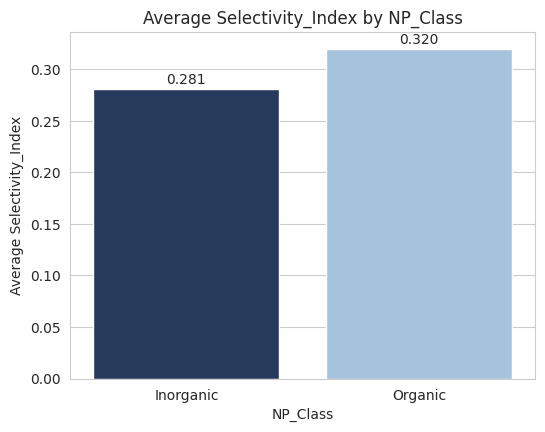

NP_Class
Inorganic    0.2808
Organic      0.3200
Name: Selectivity_Index, dtype: float64


In [ ]:
# Avg Selectivity_Index by NP_Class
npc_sel = df.groupby('NP_Class')['Selectivity_Index'].mean()

plt.figure(figsize=(6, 4.5))
sns.barplot(x=npc_sel.index, y=npc_sel.values, palette=['#1F3864','#9DC3E6'])
plt.ylabel('Average Selectivity_Index')
plt.title('Average Selectivity_Index by NP_Class')
for i, v in enumerate(npc_sel.values):
    plt.text(i, v + 0.005, f'{v:.3f}', ha='center')
plt.show()
print(npc_sel.round(4))

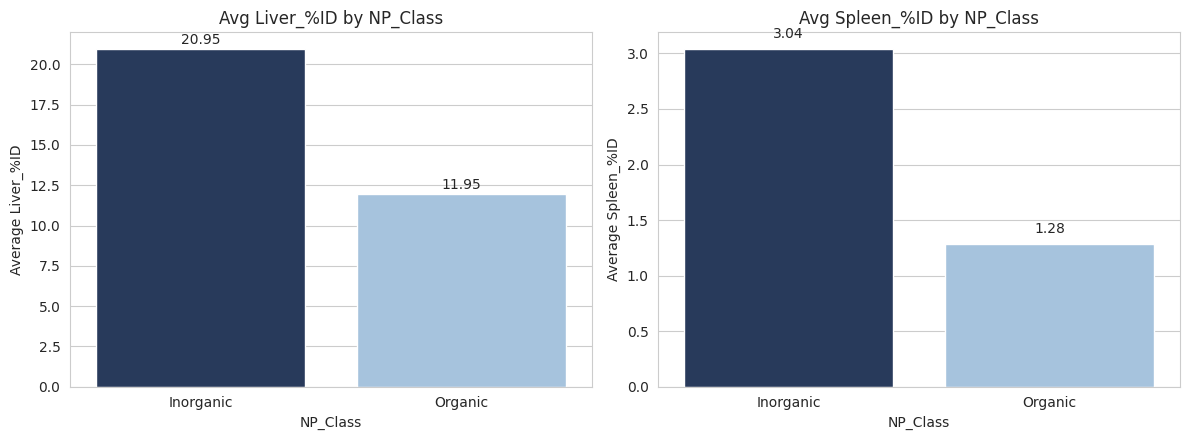

Liver: NP_Class
Inorganic    20.95
Organic      11.95
Name: Liver_%ID, dtype: float64
Spleen: NP_Class
Inorganic    3.04
Organic      1.28
Name: Spleen_%ID, dtype: float64


In [ ]:
# Avg Liver_%ID and Spleen_%ID by NP_Class (side-by-side)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

npc_liver = df.groupby('NP_Class')['Liver_%ID'].mean()
sns.barplot(x=npc_liver.index, y=npc_liver.values, ax=axes[0], palette=['#1F3864','#9DC3E6'])
axes[0].set_ylabel('Average Liver_%ID')
axes[0].set_title('Avg Liver_%ID by NP_Class')
for i, v in enumerate(npc_liver.values):
    axes[0].text(i, v + 0.3, f'{v:.2f}', ha='center')

npc_spleen = df.groupby('NP_Class')['Spleen_%ID'].mean()
sns.barplot(x=npc_spleen.index, y=npc_spleen.values, ax=axes[1], palette=['#1F3864','#9DC3E6'])
axes[1].set_ylabel('Average Spleen_%ID')
axes[1].set_title('Avg Spleen_%ID by NP_Class')
for i, v in enumerate(npc_spleen.values):
    axes[1].text(i, v + 0.1, f'{v:.2f}', ha='center')

plt.tight_layout()
plt.show()
print("Liver:", npc_liver.round(2))
print("Spleen:", npc_spleen.round(2))

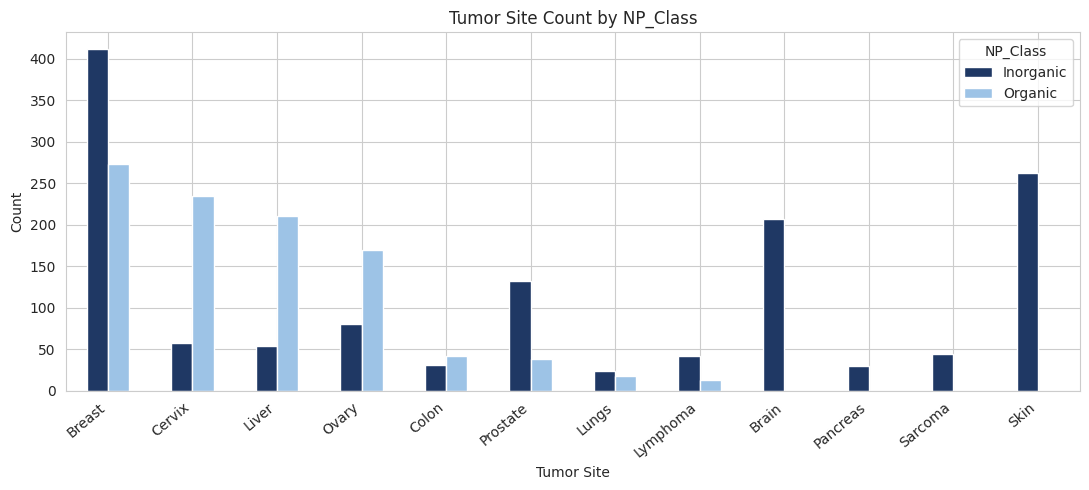

In [ ]:
# Tumor Site Count by NP_Class
ct95 = pd.crosstab(df['NP_Class'], df['Tumor Site']).T

ct95 = ct95.sort_values('Organic', ascending=False)

ct95.plot(
    kind='bar',
    figsize=(11,5),
    color=['#1F3864', '#9DC3E6']
)

plt.ylabel('Count')
plt.title('Tumor Site Count by NP_Class')
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.show()

---
## Summary

| # | Category | Key Analysis Performed |
|---|----------|------------------------|
| 1 | Overview & Dataset Summary | 2,374 records · 84 NPs · 12 tumor sites · 17 organs |
| 2 | Nanoparticle Physical Design | Size, Zeta, Shape, Core material vs. Tumor_%ID |
| 3 | Targeting Strategy Performance | Active vs. Passive across Tumor_%ID, Efficiency, Selectivity |
| 4 | Tumor Biology & Organ Targeting | Tumor site/cell distributions, full organ biodistribution ranking |
| 5 | Surface Coating & Shell Analysis | Shell Type and PEGylation vs. Tumor_%ID and Selectivity |
| 6 | Time Point & Dosage Analysis | Temporal Tumor_%ID / Liver_%ID / Spleen_%ID patterns, dosage correlations |
| 7 | Responsive Release Mechanisms | 6 release types vs. Tumor_%ID, Selectivity, Efficiency |
| 8 | Selectivity & Efficiency Performance | Distribution, NP_Class comparison, Exceptional-NP profile |
| 9 | Inorganic vs. Organic NPs Comparison | Core material, size, tumor site, liver/spleen, release by NP_Class |


---
*EDA (Python Analysis) complete — ready for Dashboard / Power BI stage.*